In [48]:
# Load Dataset
import pandas as pd

housing_dataset = "data/Housing.csv"
df = pd.read_csv(housing_dataset)
print(df) # Prints out first 5 and last 5 tuples
print(df.columns) # Prints out all columns

        price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       no   

    hotwaterheating aircond

In [49]:
# Preprocessing Part 1
# Associate X and y values

X = df.drop(columns=["price"])
y = df["price"]

# print(X.shape)
# print(y.shape)

In [50]:
# Preprocessing Part 2
# Need to deal with categorical data

X_encoded = pd.get_dummies(X, drop_first=True) # One-hot encoding for categorical variables
# print(X_encoded.head())

In [51]:
# Train-Test Split 1: 70/30
# Train: Trains model
# Test: Evaluates model performance
from sklearn.model_selection import train_test_split
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=RANDOM_STATE)
# print("X_train: " + str(X_train.shape))
# print("X_test: " + str(X_test.shape))
# print("y_train: " + str(y_train.shape))
# print("y_test: " + str(y_test.shape))

In [52]:
# Preprocessing Part 3 - Pipelines and Grid Search
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline

# Model 1 - Multiple Linear Regression (Base Model)
pipeline_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Model 2 - Interaction Terms
pipeline_inter = Pipeline([
    ("inter", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Model 3 - Lasso
pipeline_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso())
])

# Model 4 - Ridge
pipeline_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

# Model 5 - Lasso + Interaction
pipeline_lasso_inter = Pipeline([
    ("inter", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", Lasso())
])

# Model 6 - Ridge + Interaction
pipeline_ridge_inter = Pipeline([
    ("inter", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", Ridge())
])


In [53]:
# Model 1 - Multiple Linear Regression (Base Model)
from sklearn.model_selection import cross_val_score

cv_base = cross_val_score(pipeline_base, X_train, y_train, cv=5, scoring='r2')
cv_base_mean = cv_base.mean()
print("\nModel 1 - Multiple Linear Regression (Base Model)")
print(f"CV R²: {cv_base_mean:.3f}")


Model 1 - Multiple Linear Regression (Base Model)
CV R²: 0.626


In [54]:
# Model 2 - Interaction Terms

cv_inter = cross_val_score(pipeline_inter, X_train, y_train, cv=5, scoring='r2')
cv_inter_mean = cv_inter.mean()
print("\nModel 2 - Interaction Terms")
print(f"CV R²: {cv_inter_mean:.3f}")


Model 2 - Interaction Terms
CV R²: 0.309


In [55]:
# Model 3 - Lasso (L1), Model 4 - Ridge (L2)
from sklearn.model_selection import GridSearchCV

alpha_values = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0, 100000.0, 1000000.0]
params_lasso = {"model__alpha": alpha_values}
params_ridge = {"model__alpha": alpha_values}

lasso_search = GridSearchCV(pipeline_lasso, params_lasso, cv=5, scoring='r2')
lasso_search.fit(X_train, y_train)
best_lasso = lasso_search.best_estimator_
best_alpha_lasso = lasso_search.best_params_["model__alpha"]
cv_r2_lasso = lasso_search.best_score_
print("\nModel 3 - Lasso")
print(f"Best alpha: {best_alpha_lasso}")
print(f"CV R²: {cv_r2_lasso:.3f}")

ridge_search = GridSearchCV(pipeline_ridge, params_ridge, cv=5, scoring='r2')
ridge_search.fit(X_train, y_train)
best_ridge = ridge_search.best_estimator_
best_alpha_ridge = ridge_search.best_params_["model__alpha"]
cv_r2_ridge = ridge_search.best_score_
print("\nModel 4 - Ridge")
print(f"Best alpha: {best_alpha_ridge}")
print(f"CV R²: {cv_r2_ridge:.3f}")


Model 3 - Lasso
Best alpha: 10000.0
CV R²: 0.627

Model 4 - Ridge
Best alpha: 100.0
CV R²: 0.629


In [56]:
# Model 5 - Ridge + Interaction, Model 6 - Lasso + Interaction
from sklearn.model_selection import GridSearchCV
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

alpha_values = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0, 100000.0, 1000000.0]
params_lasso_inter = {"model__alpha": alpha_values}
params_ridge_inter = {"model__alpha": alpha_values}

lasso_inter_search = GridSearchCV(pipeline_lasso_inter, params_lasso_inter, cv=5, scoring='r2')
lasso_inter_search.fit(X_train, y_train)
best_lasso_inter = lasso_inter_search.best_estimator_
best_alpha_lasso_inter = lasso_inter_search.best_params_["model__alpha"]
cv_r2_lasso_inter = lasso_inter_search.best_score_
print("\nModel 5 - Lasso + Interaction")
print(f"Best alpha: {best_alpha_lasso_inter}")
print(f"CV R²: {cv_r2_lasso_inter:.3f}")  

ridge_inter_search = GridSearchCV(pipeline_ridge_inter, params_ridge_inter, cv=5, scoring='r2')
ridge_inter_search.fit(X_train, y_train)
best_ridge_inter = ridge_inter_search.best_estimator_
best_alpha_ridge_inter = ridge_inter_search.best_params_["model__alpha"]
cv_r2_ridge_inter = ridge_inter_search.best_score_
print("\nModel 6 - Ridge + Interaction")
print(f"Best alpha: {best_alpha_ridge_inter}")
print(f"CV R²: {cv_r2_ridge_inter:.3f}")


Model 5 - Lasso + Interaction
Best alpha: 100000.0
CV R²: 0.643

Model 6 - Ridge + Interaction
Best alpha: 100.0
CV R²: 0.637


In [57]:
# Model Results
results = pd.DataFrame({
    "Model": [
        "Multiple (Base) Linear Regression",
        "Interaction Terms",
        "Lasso",
        "Ridge",
        "Lasso + Interaction",
        "Ridge + Interaction"
    ],
    "CV R²": [
        cv_base_mean,
        cv_inter_mean,
        cv_r2_lasso,
        cv_r2_ridge,
        cv_r2_lasso_inter,
        cv_r2_ridge_inter
    ]
})

results = results.sort_values(by="CV R²", ascending=False)
print(f"\nModel Selection Results: \n{results}")

# Output
# Model Selection Results: 
#                                Model     CV R²
# 4                Lasso + Interaction  0.643143
# 5                Ridge + Interaction  0.636992
# 3                              Ridge  0.628983
# 2                              Lasso  0.626658
# 0  Multiple (Base) Linear Regression  0.626062
# 1                  Interaction Terms  0.308860


Model Selection Results: 
                               Model     CV R²
4                Lasso + Interaction  0.643143
5                Ridge + Interaction  0.636992
3                              Ridge  0.628983
2                              Lasso  0.626658
0  Multiple (Base) Linear Regression  0.626062
1                  Interaction Terms  0.308860


In [58]:
# # Model Selection and Evaluation
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error

y_pred_test = best_lasso_inter.predict(X_test)

r2_test = r2_score(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = root_mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"Test R²: {r2_test:.4f}")
print(f"Test MSE: {mse_test:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")
print(f"Test MAE: {mae_test:.4f}")

Test R²: 0.6487
Test MSE: 1512981231184.2712
Test RMSE: 1230033.0204
Test MAE: 926877.7258


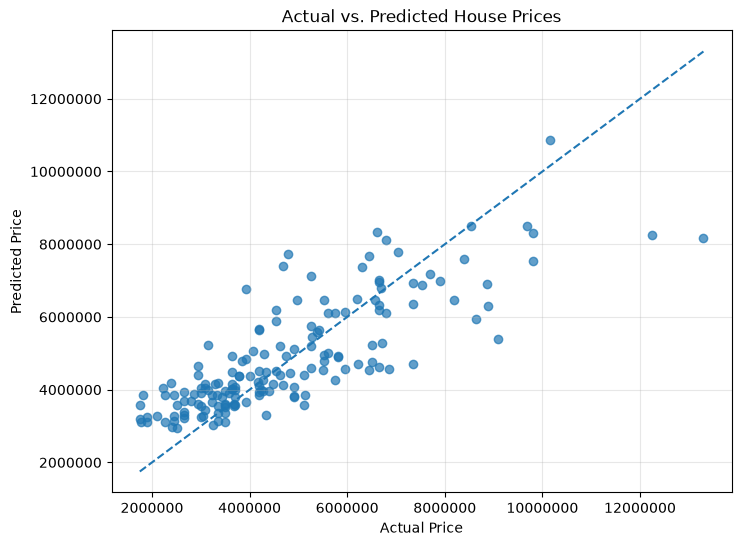

In [59]:
# Visualization Part 1 - Actual vs Predicted Values Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.7)
min_price = min(y_test.min(), y_pred_test.min())
max_price = max(y_test.max(), y_pred_test.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs. Predicted House Prices")

plt.ticklabel_format(style="plain", axis="both")
plt.grid(alpha=0.3)
plt.show()

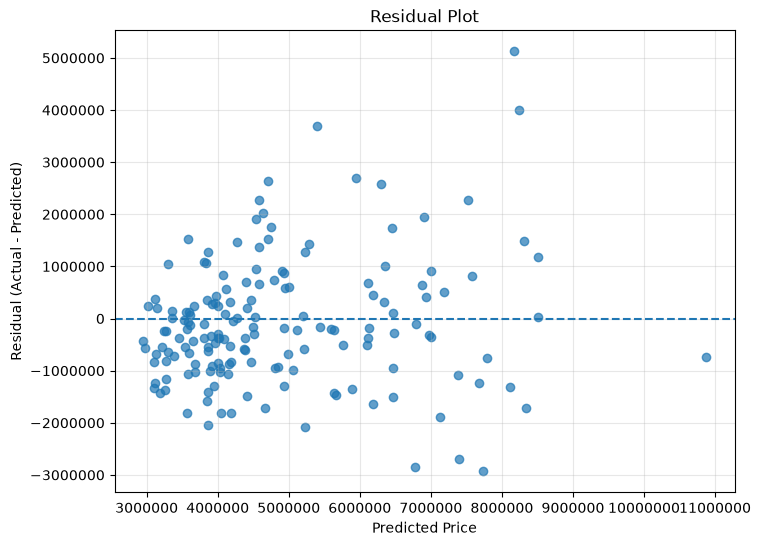

In [60]:
# Visualization Part 2 - Residual Plot
import matplotlib.pyplot as plt

residuals = y_test - y_pred_test

plt.figure(figsize=(8, 6))

plt.scatter(y_pred_test, residuals, alpha=0.7)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")

plt.ticklabel_format(style="plain", axis="both")
plt.grid(alpha=0.3)
plt.show()

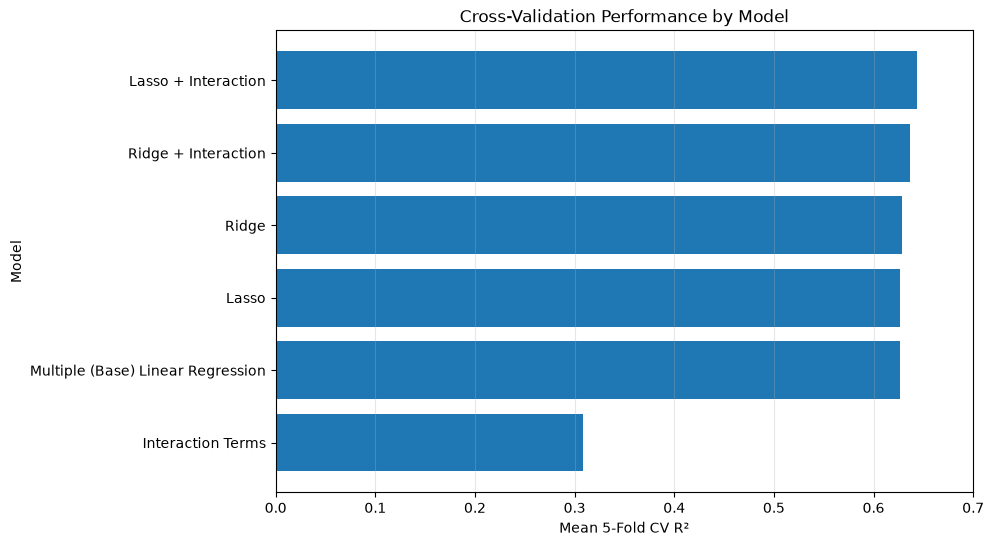

In [61]:
# Visualization Part 3 - Model Comparison Bar Chart
results_sorted = results.sort_values("CV R²")

plt.figure(figsize=(9, 6))

plt.barh(
    results_sorted["Model"],
    results_sorted["CV R²"]
)

plt.xlabel("Mean 5-Fold CV R²")
plt.ylabel("Model")
plt.title("Cross-Validation Performance by Model")
plt.xlim(0, 0.7)

plt.grid(axis="x", alpha=0.3)
plt.show()

Total features: 91
Retained: 23
Eliminated: 68

Eliminated/Zero coefficient features:
                                    Feature  Coefficient
0                                      area          0.0
49                     stories basement_yes          0.0
50              stories hotwaterheating_yes          0.0
52                     stories prefarea_yes          0.0
53  stories furnishingstatus_semi-furnished          0.0
54     stories furnishingstatus_unfurnished         -0.0
55                     parking mainroad_yes          0.0
60                     parking prefarea_yes          0.0
61  parking furnishingstatus_semi-furnished         -0.0
62     parking furnishingstatus_unfurnished         -0.0

Most influential features:
                          Feature    Coefficient  Absolute Coefficient
14                 area bathrooms  406398.838374         406398.838374
15                   area stories  318208.992344         318208.992344
43         bathrooms prefarea_yes  191164.7011

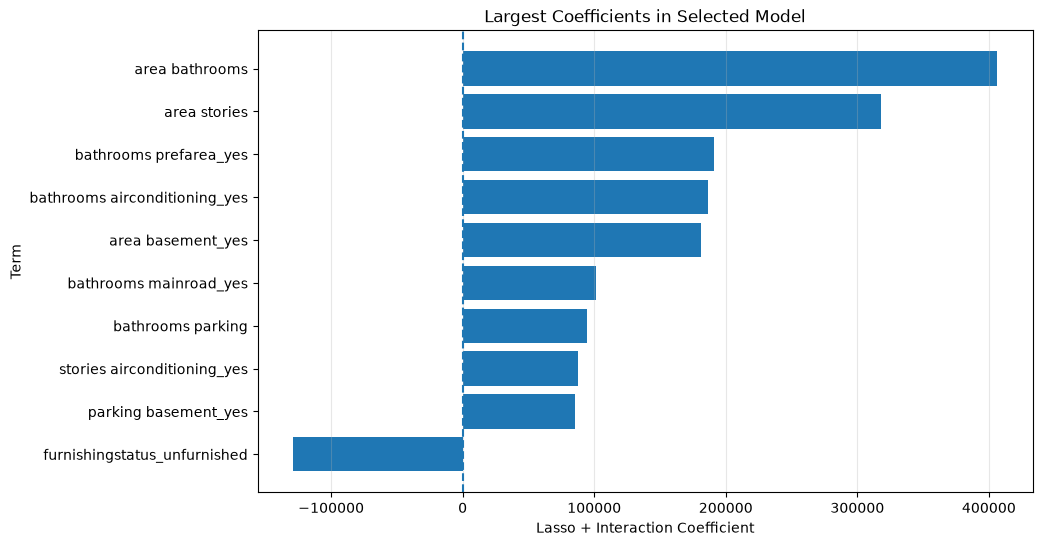

In [62]:
# Feature Extraction

feature_names = best_lasso_inter.named_steps["inter"].get_feature_names_out(X_train.columns)
coefficients = best_lasso_inter.named_steps["model"].coef_

feature_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

eliminated_features = feature_coefficients[feature_coefficients["Coefficient"] == 0]
feature_coefficients["Absolute Coefficient"] = (
    feature_coefficients["Coefficient"].abs()
)
strongest_features = feature_coefficients.sort_values("Absolute Coefficient", ascending=False)
retained_features = feature_coefficients[feature_coefficients["Coefficient"] != 0]

print("Total features:", len(feature_coefficients))
print("Retained:", len(retained_features))
print("Eliminated:", len(eliminated_features))

print("\nEliminated/Zero coefficient features:")
print(eliminated_features.sort_values("Coefficient", ascending=True).head(10))
print("\nMost influential features:")
print(strongest_features.head(10))

# Visualization Part 4 - Feature Importance Bar Chart
top_features = strongest_features.head(10).sort_values("Coefficient")
plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)
plt.xlabel("Lasso + Interaction Coefficient")
plt.ylabel("Term")
plt.title("Largest Coefficients in Selected Model")
plt.axvline(0, linestyle="--")
plt.grid(axis="x", alpha=0.3)
plt.show()